# **CÁPITULO 4 - Efeitos Térmicos**

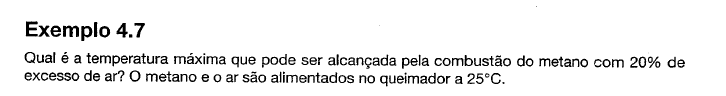

In [ ]:
import numpy as np
from numpy import array

# @author: nogfe4
# CH4 + 2O2 -> CO2 + 2H20

# Definindo a função de integração que calcula o DeltaH (essa função será zerada no N.R. para acharmos o valor de T):
def MCPH(T0,T,A,B,C,D):
  return  R * (A* (T - T0) + (B/2) * (T**2 - T0**2) + (C/3) * (T**3 - T0**3) -  D * ((1/T)-(1/T0)))

#Dados
R = 8.314;
del_H_CO2 = -393509;		#Tabela C.4
del_H_O2 = -241818;			#Tabela C.4
del_H_CH4 = -74520;			#Tabela C.4
del_H_298 = del_H_CO2+(2*del_H_O2)-del_H_CH4;
del_Hp = -del_H_298;

# Cálculos
#Número de Mols
n_CH4 = 1;
n_O2 = 2+(0.2*2);			#20% Excesso
n_N2 = n_O2*(79./21);
# Mols dos produtos (CO2, H2O, O2, N2)
np_array = array([1, 2, 0.4, 9.03])

# Coeficientes das propriedades caloríficas (tabela C.1)
A = array([5.457, 3.470, 3.639, 3.280])
B = (10**-3) * array([1.045, 1.450, 0.506, 0.593])
C = (10**-6) * array([0, 0, 0, 0])
D = (10**5) * array([-1.157, 0.121, -0.227, 0.040])

# Propriedades caloríficas totais dos produtos
E_A = np.sum(np_array * A)
E_B = np.sum(np_array * B)
E_C = np.sum(np_array * C)
E_D = np.sum(np_array * D)

# Inicialização
T0 = 298.15
T_guess = 300 # Chute inicial

def MCPH_derivative(T, A, B, C, D):
    "Calcula a derivada da função MCPH em relação a T."
    return R*(A + (B * T) + (C * T * 2) - (D * (1/(T)**2)) )

# Método de Newton-Raphson
error_tolerance = 1e-6 #Tolerância
max_iterations = 1000 #Iterações máximas
iteration = 0

while iteration < max_iterations:
    # Função e sua derivada
    MCPH_value = MCPH(T0, T_guess, E_A, E_B, E_C, E_D)
    MCPH_prime = MCPH_derivative(T_guess, E_A, E_B, E_C, E_D)

    # Resíduo
    f_T = MCPH_value - del_Hp

    # Atualização de Newton-Raphson
    T_new = T_guess - f_T / MCPH_prime

    # Verifica a convergência
    if abs(T_new - T_guess) < error_tolerance:
        break

    T_guess = T_new
    iteration += 1

# Resultado:
if iteration >= max_iterations:
    print("O método de Newton-Raphson não convergiu.")
else:
    print(f"Resultado: {round(T_guess)} K")

Resultado: 2066 K


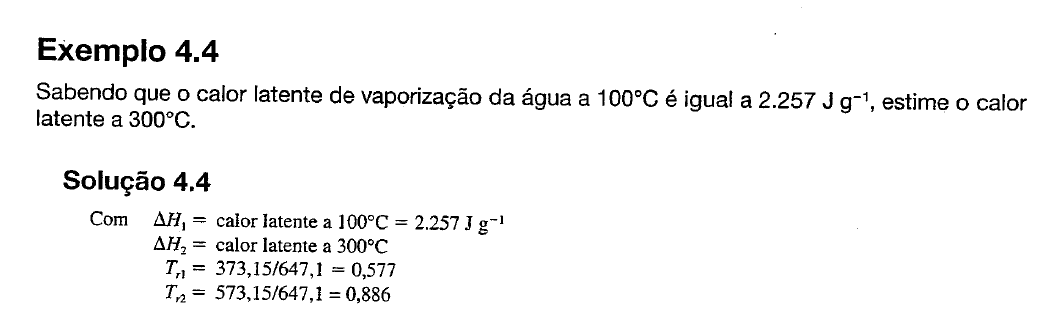

In [ ]:
# @author: nogfe4
dh1 = 2257  # [J/g] - Calor latente a 100 graus
T1 = 100 + 273.15 # [K]
T2 = 300 + 273.15 # [K]
Tr1 = (T1/647.1)
Tr2 = (T2/647.1)

dh2 = dh1*(((1-Tr2)/(1-Tr1))**(0.38))
print(f"O Valor dado nas tabelas de vapor é de: {round(dh2, 2)} J/g")

O Valor dado nas tabelas de vapor é de: 1372.19 J/g


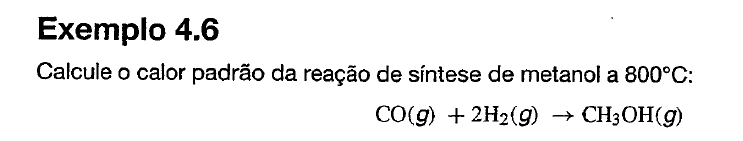

In [ ]:
import numpy as np
from numpy import array

# @author: nogfe4
# CO + 2H2 -> CH3OH

# Definindo a função
def IDCPH(T0,T,A,B,C,D):
    t = T/T0;
    return (A+((B/2)*T0*(t+1))+((C/3)*T0*T0*((t**2)+t+1))+(D/(t*T0*T0)))*(T-T0)

#Dados
R = 8.314;
del_H_CO = -110525;			#Tabela C.4
del_H2 = 0;			#Tabela C.4
del_H_CH3OH = -200660;			#Tabela C.4
dh_0 = del_H_CH3OH - (del_H_CO - del_H2)


# Cálculos
#Número de Mols
n_CH3OH = 1;
n_CO = -1;
n_H2 = -2;
np_array = array([1, -1, -2])

# Coeficientes das propriedades caloríficas (Tabela C.1)
A = array([2.211, 3.376, 3.249])
B = (10**-3) * array([12.216, 0.557, 0.422])
C = (10**-6) * array([-3.450, 0, 0])
D = (10**5) * array([0, -0.031, 0.083])

# Propriedades caloríficas totais dos produtos
E_A = np.sum(np_array * A)
E_B = np.sum(np_array * B)
E_C = np.sum(np_array * C)
E_D = np.sum(np_array * D)


#Temperaturas:
T0 = 298.15
T = 800 + 273.15

#Cálculo do Calor padrão de reação:
ICPH_value = IDCPH(T0, T, E_A, E_B, E_C, E_D)
Dh_0 = dh_0 + (R*ICPH_value)

print(f"O Calor padrão de reação é: {round(Dh_0)} J")

O Calor padrão de reação é: -103566 J
